In [1]:
import os

import pandas as pd
import numpy as np
import typing
import matplotlib.pyplot as plt

import keras
from keras import layers
from keras import ops

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.nn.functional import mse_loss

In [2]:
route_distances = pd.read_csv("/content/PeMSD7_W_228.csv", header=None).to_numpy()
speeds_array = pd.read_csv("/content/PeMSD7_V_228.csv", header=None).to_numpy()

print(f"route_distances shape={route_distances.shape}")
print(f"speeds_array shape={speeds_array.shape}")

route_distances shape=(228, 228)
speeds_array shape=(8831, 228)


In [3]:
def preprocess(data_array: torch.Tensor, train_size: float, val_size: float):
    """Splits data into train/val/test sets and normalizes the data.

    Args:
        data_array: Tensor of shape `(num_time_steps, num_routes)`
        train_size: Proportion of the dataset to include in the train split.
        val_size: Proportion of the dataset to include in the validation split.

    Returns:
        `train_tensor`, `val_tensor`, `test_tensor`
    """
    num_time_steps = data_array.size(0)
    num_train = int(num_time_steps * train_size)
    num_val = int(num_time_steps * val_size)

    # 切分數據
    train_tensor = data_array[:num_train]
    mean = train_tensor.mean(dim=0, keepdim=True)
    std = train_tensor.std(dim=0, keepdim=True)

    # 標準化數據
    train_tensor = (train_tensor - mean) / std
    val_tensor = (data_array[num_train : num_train + num_val] - mean) / std
    test_tensor = (data_array[num_train + num_val :] - mean) / std

    return train_tensor, val_tensor, test_tensor

# 轉換 speeds_array 成 PyTorch Tensor
speeds_tensor = torch.tensor(speeds_array, dtype=torch.float32)

# 使用 preprocess 函數
train_tensor, val_tensor, test_tensor = preprocess(speeds_tensor, train_size=0.7, val_size=0.2)

# 輸出結果
print(f"train set size: {train_tensor.shape}")
print(f"validation set size: {val_tensor.shape}")
print(f"test set size: {test_tensor.shape}")

torch.save(train_tensor, 'train_tensor.pt')
torch.save(val_tensor, 'val_tensor.pt')
torch.save(test_tensor, 'test_tensor.pt')

train set size: torch.Size([6181, 228])
validation set size: torch.Size([1766, 228])
test set size: torch.Size([884, 228])


In [4]:
from torch.utils.data import Dataset, DataLoader
class TimeSeriesDataset(Dataset):
    def __init__(self, data_array, input_sequence_length, forecast_horizon):
        self.data_array = data_array
        self.input_sequence_length = input_sequence_length
        self.forecast_horizon = forecast_horizon
        self.num_samples = data_array.size(0) - input_sequence_length - forecast_horizon + 1

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        inputs = self.data_array[idx: idx + self.input_sequence_length]  # shape: (input_sequence_length, num_routes)
        targets = self.data_array[idx + self.input_sequence_length: idx + self.input_sequence_length + self.forecast_horizon]
        return inputs, targets


# 設定參數
batch_size = 64
input_sequence_length = 36
forecast_horizon = 12
multi_horizon = True

# 創建 Dataset 和 DataLoader
train_dataset = TimeSeriesDataset(train_tensor, input_sequence_length, forecast_horizon)
val_dataset = TimeSeriesDataset(val_tensor, input_sequence_length, forecast_horizon)
test_dataset = TimeSeriesDataset(test_tensor, input_sequence_length, forecast_horizon)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")


for inputs, targets in train_loader:
    print(f"Batch input shape: {inputs.shape}")
    print(f"Batch target shape: {targets.shape}")
    break

Number of training samples: 6134
Number of validation samples: 1719
Number of test samples: 837
Batch input shape: torch.Size([64, 36, 228])
Batch target shape: torch.Size([64, 12, 228])


In [5]:
def compute_adjacency_matrix(
    route_distances: np.ndarray, sigma2: float, epsilon: float
):
    """Computes the adjacency matrix from distances matrix.

    It uses the formula in https://github.com/VeritasYin/STGCN_IJCAI-18#data-preprocessing to
    compute an adjacency matrix from the distance matrix.
    The implementation follows that paper.

    Args:
        route_distances: np.ndarray of shape `(num_routes, num_routes)`. Entry `i,j` of this array is the
            distance between roads `i,j`.
        sigma2: Determines the width of the Gaussian kernel applied to the square distances matrix.
        epsilon: A threshold specifying if there is an edge between two nodes. Specifically, `A[i,j]=1`
            if `np.exp(-w2[i,j] / sigma2) >= epsilon` and `A[i,j]=0` otherwise, where `A` is the adjacency
            matrix and `w2=route_distances * route_distances`

    Returns:
        A boolean graph adjacency matrix.
    """
    num_routes = route_distances.shape[0]
    route_distances = route_distances / 10000.0
    w2, w_mask = (
        route_distances * route_distances,
        np.ones([num_routes, num_routes]) - np.identity(num_routes),
    )
    return (np.exp(-w2 / sigma2) >= epsilon) * w_mask

In [6]:
class GraphInfo:
    def __init__(self, edges: typing.Tuple[list, list], num_nodes: int):
        self.edges = edges
        self.num_nodes = num_nodes


sigma2 = 0.1
epsilon = 0.5
adjacency_matrix = compute_adjacency_matrix(route_distances, sigma2, epsilon)
node_indices, neighbor_indices = np.where(adjacency_matrix == 1) #找出圖中的所有邊
graph = GraphInfo(
    edges=(node_indices.tolist(), neighbor_indices.tolist()),
    num_nodes=adjacency_matrix.shape[0],
)
print(f"number of nodes: {graph.num_nodes}, number of edges: {len(graph.edges[0])}")

number of nodes: 228, number of edges: 1664


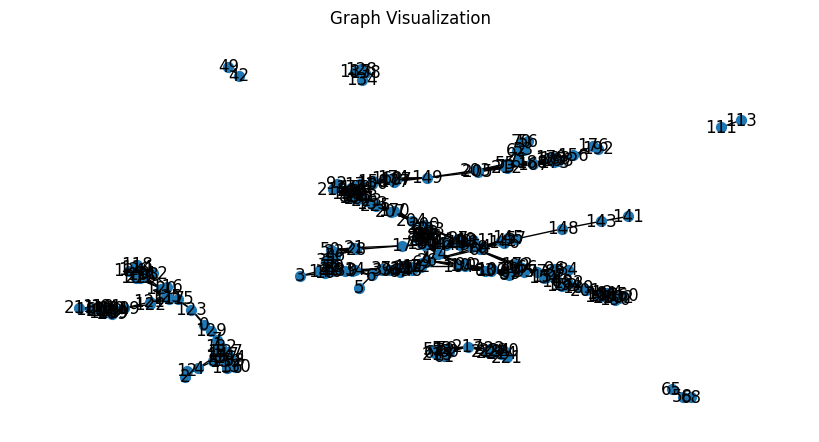

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_edges_from(zip(graph.edges[0], graph.edges[1]))

plt.figure(figsize=(8, 4))
nx.draw(G, node_size=50, with_labels=True)
plt.title("Graph Visualization")
plt.show()

In [8]:
class GraphConv(nn.Module):
    def __init__(
        self,
        in_feat,
        out_feat,
        graph_info,
        aggregation_type="mean",
        combination_type="concat",
        activation=None
    ):
        super(GraphConv, self).__init__()
        self.in_feat = in_feat
        self.out_feat = out_feat
        self.graph_info = graph_info
        self.aggregation_type = aggregation_type
        self.combination_type = combination_type

        self.weight = nn.Parameter(torch.empty(in_feat, out_feat))
        nn.init.xavier_uniform_(self.weight)
        self.activation = getattr(F, activation) if activation else None

    def aggregate(self, neighbour_representations, dst_nodes, num_nodes):
        """
        Aggregates neighbor representations.
        Args:
            neighbour_representations: Tensor of shape [num_edges, batch_size * seq_len, in_feat]
            dst_nodes: Tensor of shape [num_edges]
            num_nodes: Total number of nodes
        Returns:
            Aggregated tensor of shape [num_nodes, batch_size * seq_len, in_feat]
        """
        aggregated = torch.zeros(
            (num_nodes, neighbour_representations.size(1), neighbour_representations.size(2)),
            device=neighbour_representations.device
        )
        aggregated.index_add_(0, dst_nodes, neighbour_representations)
        return aggregated

    def forward(self, features):
        """
        Args:
            features: Tensor of shape (num_nodes, batch_size * seq_len, in_feat)
        Returns:
            Updated node features: Tensor of shape (num_nodes, batch_size * seq_len, out_feat)
        """
        src_nodes = torch.tensor(self.graph_info.edges[1], dtype=torch.long, device=features.device)
        dst_nodes = torch.tensor(self.graph_info.edges[0], dtype=torch.long, device=features.device)

        # Gather neighbor features
        neighbour_representations = features[src_nodes]  # (num_edges, batch_size * seq_len, in_feat)

        # Aggregate neighbor features
        aggregated_messages = self.aggregate(neighbour_representations, dst_nodes, features.size(0))

        # Linear transformation
        nodes_representation = torch.matmul(features, self.weight)  # (num_nodes, batch_size * seq_len, out_feat)

        # Combine representations
        if self.combination_type == "concat":
            h = torch.cat([nodes_representation, aggregated_messages], dim=-1)
        elif self.combination_type == "add":
            h = nodes_representation + aggregated_messages
        else:
            raise ValueError(f"Invalid combination type: {self.combination_type}")

        # Apply activation
        if self.activation:
            h = self.activation(h)
        return h

In [ ]:
class LSTMGC(nn.Module):
    def __init__(
        self,
        in_feat,
        out_feat,
        lstm_units,
        input_seq_len,
        output_seq_len,
        graph_info,
    ):
        """
        Args:
            in_feat: Input feature dimension.
            out_feat: Output feature dimension from GraphConv.
            lstm_units: Number of units in the LSTM layer.
            input_seq_len: Length of the input sequence.
            output_seq_len: Length of the output sequence.
            graph_info: Graph structure information.
        """
        super(LSTMGC, self).__init__()
        self.graph_conv = GraphConv(in_feat, out_feat, graph_info, combination_type="concat")
        self.lstm = nn.LSTM(input_size=out_feat + in_feat, hidden_size=lstm_units, batch_first=True)
        self.dense = nn.Sequential(
            nn.Linear(lstm_units, lstm_units // 2),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(lstm_units // 2, output_seq_len)
        )

    def forward(self, inputs):
        """
        Args:
            inputs: Tensor of shape (batch_size, input_seq_len, num_nodes, in_feat)
        Returns:
            Tensor of shape (batch_size, output_seq_len, num_nodes)
        """
        batch_size, seq_len, num_nodes, in_feat = inputs.shape

        # Step 1: Reshape for GraphConv
        inputs = inputs.permute(2, 0, 1, 3)  # (num_nodes, batch_size, input_seq_len, in_feat)
        inputs = inputs.reshape(num_nodes, batch_size * seq_len, in_feat)  # Flatten time and batch dims

        # Step 2: Graph Convolution
        gcn_out = self.graph_conv(inputs)  # (num_nodes, batch_size * seq_len, out_feat)
        gcn_out = gcn_out.view(num_nodes, batch_size, seq_len, -1)  # (num_nodes, batch_size, input_seq_len, out_feat)

        # Step 3: Reshape for LSTM
        gcn_out = gcn_out.permute(1, 2, 0, 3)  # (batch_size, input_seq_len, num_nodes, out_feat)
        gcn_out = gcn_out.reshape(batch_size * num_nodes, seq_len, -1)  # (batch_size * num_nodes, input_seq_len, out_feat)

        # Step 4: LSTM
        lstm_out, _ = self.lstm(gcn_out)  # (batch_size * num_nodes, input_seq_len, lstm_units)
        lstm_out = lstm_out[:, -1, :]  # Use last time step output (batch_size * num_nodes, lstm_units)

        # Step 5: Dense Layer
        dense_out = self.dense(lstm_out)  # (batch_size * num_nodes, output_seq_len)

        # Step 6: Reshape back to original dimensions
        output = dense_out.view(batch_size, num_nodes, -1)  # (batch_size, num_nodes, output_seq_len)
        output = output.permute(0, 2, 1)  # (batch_size, output_seq_len, num_nodes)

        return output


In [ ]:
# Model Hyperparameters
in_feat = 1
out_feat = 12
lstm_units = 64
input_sequence_length = 36
forecast_horizon = 12
batch_size = 128
epochs = 100

# Graph Info
graph_info = GraphInfo(edges=(node_indices.tolist(), neighbor_indices.tolist()), num_nodes=route_distances.shape[0])

# Model Initialization
model = LSTMGC(
    in_feat,
    out_feat,
    lstm_units,
    input_sequence_length,
    forecast_horizon,
    graph_info
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-2)
loss_fn = nn.MSELoss()
best_val_loss = float('inf')

# Training Loop with Validation
for epoch in range(epochs):
    # ---- Training Phase ----
    model.train()
    total_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        # Forward pass
        outputs = model(inputs.unsqueeze(-1))  # Add in_feat dimension
        loss = loss_fn(outputs, targets)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # ---- Validation Phase ----
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for val_inputs, val_targets in val_loader:
            val_inputs, val_targets = val_inputs.to(device), val_targets.to(device)
            val_outputs = model(val_inputs.unsqueeze(-1))
            loss = loss_fn(val_outputs, val_targets)
            val_loss += loss.item()

    # ---- Epoch Results ----
    avg_train_loss = total_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
    if avg_val_loss < best_val_loss:
      best_val_loss = avg_val_loss
      torch.save(model.state_dict(), "best_model.pth")
      print(f"Best model saved at epoch {epoch+1}")


Epoch [1/100], Train Loss: 0.8781, Val Loss: 0.9386
Best model saved at epoch 1
Epoch [2/100], Train Loss: 0.8580, Val Loss: 0.9344
Best model saved at epoch 2
Epoch [3/100], Train Loss: 0.8523, Val Loss: 0.9264
Best model saved at epoch 3
Epoch [4/100], Train Loss: 0.8444, Val Loss: 0.9112
Best model saved at epoch 4
Epoch [5/100], Train Loss: 0.8314, Val Loss: 0.8996
Best model saved at epoch 5
Epoch [6/100], Train Loss: 0.8240, Val Loss: 0.8941
Best model saved at epoch 6
Epoch [7/100], Train Loss: 0.8185, Val Loss: 0.8901
Best model saved at epoch 7
Epoch [8/100], Train Loss: 0.8145, Val Loss: 0.8868
Best model saved at epoch 8
Epoch [9/100], Train Loss: 0.8112, Val Loss: 0.8825
Best model saved at epoch 9
Epoch [10/100], Train Loss: 0.8068, Val Loss: 0.8808
Best model saved at epoch 10
Epoch [11/100], Train Loss: 0.8031, Val Loss: 0.8796
Best model saved at epoch 11
Epoch [12/100], Train Loss: 0.7988, Val Loss: 0.8770
Best model saved at epoch 12
Epoch [13/100], Train Loss: 0.7961

(1221, 12, 228)
(1221, 12, 228)
Model MSE: 0.7535


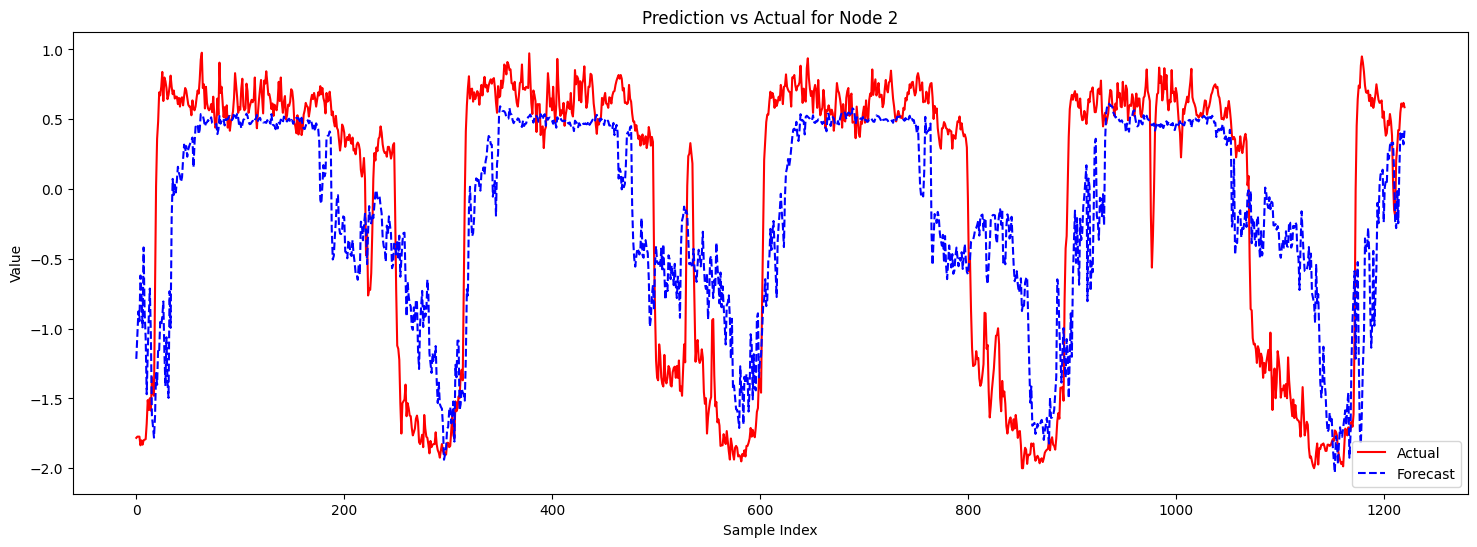

In [ ]:
# 設置模型為評估模式
model.eval()

# 初始化變數來儲存預測和真實值
all_y = []
all_y_pred = []

# 遍歷所有測試批次
with torch.no_grad():
    for x_test, y in test_loader:
        x_test, y = x_test.to(device), y.to(device)

        # 預測輸出
        y_pred = model(x_test.unsqueeze(-1))  # Add in_feat dimension

        # 收集所有批次的真實值和預測值
        all_y.append(y.cpu().numpy())
        all_y_pred.append(y_pred.cpu().numpy())

# 將所有批次的預測值和真實值拼接起來
all_y = np.concatenate(all_y, axis=0)  # Shape: (1221, output_seq_len, num_nodes)
all_y_pred = np.concatenate(all_y_pred, axis=0)
print(all_y.shape)
print(all_y_pred.shape)

# 計算整體 MSE
model_mse = np.square(all_y_pred[:, :, :] - all_y[:, :, :]).mean()
print(f"Model MSE: {model_mse:.4f}")

# 繪圖：比較實際值與預測值
node_index = 1
plt.figure(figsize=(18, 6))
plt.plot(all_y[:, 0, node_index], label="Actual", linestyle='-', color='r')     # 第一個時間步的實際值
plt.plot(all_y_pred[:, 0, node_index], label="Forecast", linestyle='--', color='b')  # 第一個時間步的預測值
plt.legend()
plt.title(f"Prediction vs Actual for Node {node_index+1}")
plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.show()


all_y shape: (1221, 12, 228)
all_y_pred shape: (1221, 12, 228)
Model MSE (Original Scale): 113.8009
Model RMSE (Original Scale): 10.6678
Model MAE (Original Scale): 7.3188


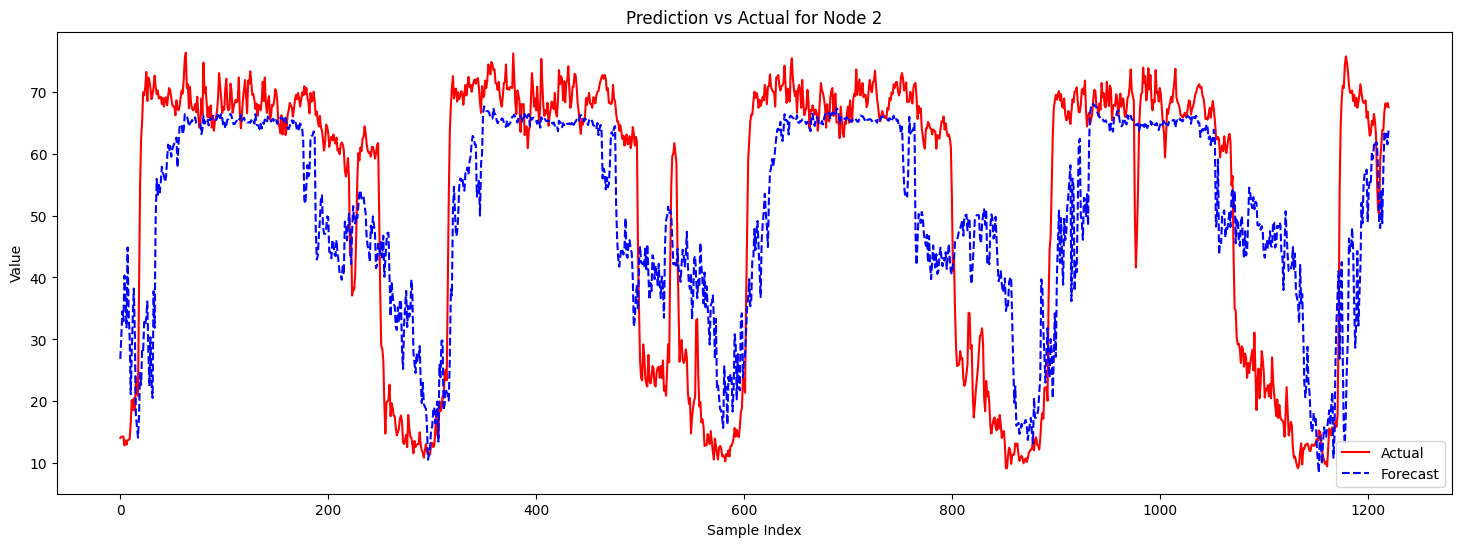

In [ ]:
# 計算 train_tensor 的 mean 和 std
num_time_steps = speeds_tensor.size(0)
num_train = int(num_time_steps * 0.7)

train_tensor_orig = speeds_tensor[:num_train]
mean = train_tensor_orig.mean(dim=0, keepdim=True)
std = train_tensor_orig.std(dim=0, keepdim=True)

mean = mean.squeeze(0)  # Shape: (num_nodes,)
std = std.squeeze(0)    # Shape: (num_nodes,)

# 轉換為 NumPy 格式
mean_np = mean.cpu().numpy()  # (num_nodes,)
std_np = std.cpu().numpy()

mean_np = mean_np.reshape(1, 1, -1)  # Shape: (1, 1, num_nodes)
std_np = std_np.reshape(1, 1, -1)    # Shape: (1, 1, num_nodes)


# 檢查形狀
print("all_y shape:", all_y.shape)  # (1221, output_seq_len, num_nodes)
print("all_y_pred shape:", all_y_pred.shape)

# 反標準化到原始尺度
all_y_orig = all_y * std_np + mean_np            # Shape: (1221, output_seq_len, num_nodes)
all_y_pred_orig = all_y_pred * std_np + mean_np  # Shape: (1221, output_seq_len, num_nodes)

# 計算 MSE（Mean Square Error）
mse = np.square(all_y_pred_orig[:, :, :] - all_y_orig[:, :, :]).mean()
rmse = np.sqrt(mse)
mae = np.abs(all_y_pred_orig[:, :, :] - all_y_orig[:, :, :]).mean()

# 輸出結果
print(f"Model MSE (Original Scale): {mse:.4f}")
print(f"Model RMSE (Original Scale): {rmse:.4f}")
print(f"Model MAE (Original Scale): {mae:.4f}")

# 繪圖：比較實際值與預測值（原始尺度）
node_index = 1
plt.figure(figsize=(18, 6))
plt.plot(all_y_orig[:, 0, node_index], label="Actual", linestyle='-', color='r')     # 第一個時間步的實際值
plt.plot(all_y_pred_orig[:, 0, node_index], label="Forecast", linestyle='--', color='b')  # 第一個時間步的預測值
plt.legend()
plt.title(f"Prediction vs Actual for Node {node_index+1}")
plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.show()